In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import glob
from lightgbm import LGBMRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.model_selection import train_test_split

In [12]:
df = pd.read_parquet("../../../train_data.parquet")

In [13]:
df.columns

Index(['game_date', 'pitch_type', 'p_throws', 'stand', 'release_speed',
       'release_height', 'release_side', 'arm_angle', 'release_extension',
       'ivb', 'hb', 'spin_rate', 'vaa', 'haa', 'plate_x', 'plate_z',
       'pitch_result', 'rv', 'fb_velo'],
      dtype='object')

In [14]:
features = ["release_speed", "release_height", "release_side", "arm_angle", "release_extension", "ivb", "hb", "spin_rate", "vaa", "haa", "plate_x", "plate_z"]
target = ["rv"]

In [19]:
def pred_fc(df, features, target, p_hand, b_hand):

    X = df[features]
    y = df[target]

    # Stage 1: find the right number of trees using a validation split
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.15, random_state=42
    )

    probe_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        n_jobs=-1,
        random_state=42
    )

    probe_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="l2",
        callbacks=[early_stopping(stopping_rounds=50), log_evaluation(period=0)]
    )

    best_n_trees = probe_model.best_iteration_
    print(f"p_hand={p_hand}, b_hand={b_hand}: best_iteration = {best_n_trees}")

    # Stage 2: refit on 100% of the data using that fixed tree count
    final_model = LGBMRegressor(
        n_estimators=best_n_trees,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        n_jobs=-1,
        random_state=42
    )

    final_model.fit(X, y)

    with open(f'fc_{p_hand}HP_{b_hand}HB.pkl', 'wb') as f:
        pickle.dump(final_model, f)

    print(f"Model for p_hand = {p_hand}, and b_hand = {b_hand} saved!")

In [20]:
df_fc = df[df["pitch_type"].isin(["FC"])]

In [21]:
for p in ["R", "L"]:
    for b in ["R", "L"]:
        df_tr = df_fc[(df_fc["p_throws"] == p) & (df_fc["stand"] == b)]
        length = len(df_tr)
        print(f"{p}HP vs {b}HB: {length}")

RHP vs RHB: 104020
RHP vs LHB: 106453
LHP vs RHB: 53117
LHP vs LHB: 18368


In [22]:
for p in ["R", "L"]:
    for b in ["R", "L"]:
        df_tr = df_fc[(df_fc["p_throws"] == p) & (df_fc["stand"] == b)]
        pred_fc(df_tr, features, target, p, b)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2732
[LightGBM] [Info] Number of data points in the train set: 88417, number of used features: 12
[LightGBM] [Info] Start training from score -0.001184
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[50]	valid_0's l2: 0.0458893
p_hand=R, b_hand=R: best_iteration = 50
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2740
[LightGBM] [Info] Number of data points in the train set: 104020, number of used features: 12
[LightGBM] [Info] Start training from score -0.000667
Model for p_hand = R, and b_hand = R saved!
[LightGBM] [Info] Auto-choosing col-wise

In [24]:
model_files = glob.glob('fc_*.pkl')

importance_records = []

for path in model_files:
    # Extract pitch and side from filename
    parts = path.replace('.pkl', '').split('_')
    pitch, side = parts[1], parts[2]

    with open(path, 'rb') as f:
        model = pickle.load(f)

    importances = model.booster_.feature_importance(importance_type='gain') 

    for feat, imp in zip(features, importances):
        importance_records.append({'p_hand': pitch, 'b_side': side, 'feature': feat, 'importance': imp})

df_imp = pd.DataFrame(importance_records)
df_imp1 = df_imp[~df_imp["feature"].isin(["plate_x", "plate_z"])]

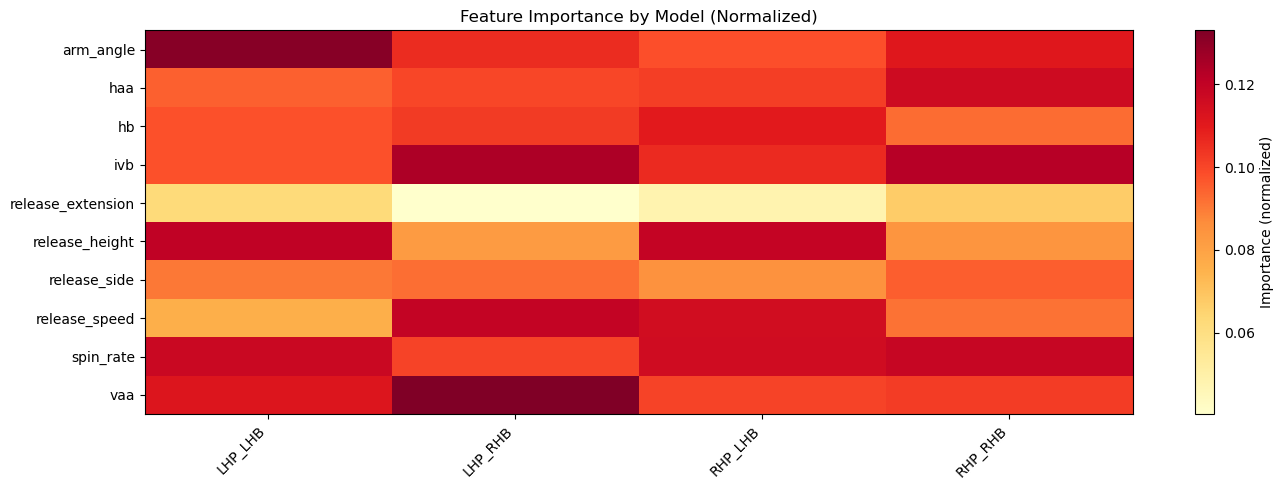

In [25]:
pivot = df_imp1.pivot_table(index='feature', columns=['p_hand', 'b_side'], values='importance')
pivot.columns = ['_'.join(c) for c in pivot.columns]

# Normalize each column to sum to 1
pivot_norm = pivot.div(pivot.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot_norm.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(pivot_norm.columns)))
ax.set_xticklabels(pivot_norm.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_norm.index)))
ax.set_yticklabels(pivot_norm.index)
plt.colorbar(im, ax=ax, label='Importance (normalized)')
plt.title('Feature Importance by Model (Normalized)')
plt.tight_layout()
plt.show()